# Lec6-GAN — Generative Adversarial Networks
### From VAE to GAN: Adversarial Generative Modeling

**Prerequisites:** Lec5-(V)AE (Autoencoder, VAE, ELBO, reparameterisation trick)

| Part | Topic | Key Ideas |
|------|-------|-----------|
| 1 | Motivation: VAE → GAN | Blurry samples, implicit vs. explicit density |
| 2 | Vanilla GAN on MNIST | Generator, Discriminator, minimax objective |
| 3 | Conditional GAN (cGAN) | Class-conditioned generation, label embedding |
| 4 | Failure Modes | Mode collapse, non-convergence, practical fixes |

---
## Part 1 — From VAE to GAN: Closing the Gap

---
### What the VAE does well — and where it struggles

Recall the VAE objective (ELBO):

$$\mathcal{L}_{\text{VAE}} = \underbrace{\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]}_{\text{reconstruction}} - \underbrace{D_{\text{KL}}(q_\phi(z|x) \| p(z))}_{\text{regularisation}}$$

The reconstruction term is typically a **pixel-wise MSE** (or BCE):

$$\log p_\theta(x|z) \propto -\|x - \hat{x}\|^2$$

This treats each pixel independently, which leads to:

- **Blurry samples** — averaging over pixel uncertainty smooths sharp edges
- **No perceptual sharpness** — MSE ignores spatial correlations (two images can be visually very different yet have the same MSE)

---
### The key insight: implicit vs. explicit density

| Model | Density | Sample quality | Training |
|-------|---------|---------------|----------|
| VAE | **Explicit** — tracks $p_\theta(x)$ via ELBO lower bound | Often blurry | Stable (one objective) |
| **GAN** | **Implicit** — no explicit $p_\theta(x)$, only a sampler $G(z)$ | Sharp | Adversarial (two objectives) |

**GAN's bet:** we don't need $p(x)$ explicitly — we just need a generator $G$ that fools a discriminator $D$ that has seen real data.  
Sharp samples emerge because $D$ penalises blurry fakes.

---
### Geometry of latent space: VAE vs. GAN

```
VAE:   z ~ N(0,I)  →  G(z)  ≈ x          (decoder is a density model, pixel-MSE)
GAN:   z ~ N(0,I)  →  G(z)  = x_fake     (generator is a mapping, no pixel loss)
                   ↑                         ↑
               same prior            but trained adversarially
```

Both map Gaussian noise → image.  The **loss function** is what changes everything.

---
## Part 2 — The GAN Framework

---
### Minimax objective

A GAN has two networks:

- **Generator** $G_\theta : \mathbb{R}^d \to \mathbb{R}^{784}$ — maps noise $z \sim \mathcal{N}(0,I)$ to fake images
- **Discriminator** $D_\phi : \mathbb{R}^{784} \to [0, 1]$ — predicts probability that an image is real

They play a **minimax game**:

$$\min_G \max_D \; V(D, G) = \mathbb{E}_{x \sim p_{\text{data}}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$

- $D$ wants to output 1 for real, 0 for fake → **maximise** $V$
- $G$ wants $D$ to output 1 for its fakes → **minimise** $V$ (equivalently, maximise $\log D(G(z))$)

---
### Optimal discriminator and global minimum

For a fixed $G$, the optimal discriminator is:

$$D^*(x) = \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_G(x)}$$

Substituting $D^*$ back, the minimax value becomes:

$$V(D^*, G) = -\log 4 + 2 \cdot \text{JSD}(p_{\text{data}} \| p_G)$$

where JSD is the Jensen-Shannon divergence.  The **global minimum** $V = -\log 4$ is achieved iff $p_G = p_{\text{data}}$.

---
### Non-saturating generator loss (practical)

The original $\log(1 - D(G(z)))$ saturates early in training (near 0 when $D$ is strong).  
In practice, the generator maximises $\log D(G(z))$ instead — **same fixed point, better gradients**:

$$\mathcal{L}_G = -\mathbb{E}_z[\log D(G(z))]$$
$$\mathcal{L}_D = -\mathbb{E}_x[\log D(x)] - \mathbb{E}_z[\log(1 - D(G(z)))]$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_openml

torch.manual_seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# ── Load MNIST ────────────────────────────────────────────────────────────────
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_all = mnist.data.astype(np.float32) / 255.0          # (70000, 784), range [0,1]
y_all = mnist.target.astype(int)

# Use 10 000 samples for fast training in lecture
N_TRAIN = 10_000
idx     = np.random.permutation(len(X_all))[:N_TRAIN]
X_train = torch.tensor(X_all[idx])
y_train = torch.tensor(y_all[idx])

train_ds  = TensorDataset(X_train, y_train)
train_dl  = DataLoader(train_ds, batch_size=128, shuffle=True, drop_last=True)

print(f'Training set: {X_train.shape}   Labels: {y_train.shape}')

Using device: cpu
Training set: torch.Size([10000, 784])   Labels: torch.Size([10000])


---
### Architecture: Generator and Discriminator (MLP)

We use simple fully-connected networks for interpretability.

- **Generator:** $z \in \mathbb{R}^{64}$ → Linear → BatchNorm → LeakyReLU → ... → 784 → Sigmoid
- **Discriminator:** $x \in \mathbb{R}^{784}$ → Linear → LeakyReLU → Dropout → ... → 1 → Sigmoid

Key design choices:
- **BatchNorm in G** — stabilises generator training, prevents gradient vanishing
- **LeakyReLU in D** — avoids dead neurons, better gradient flow to G
- **Dropout in D** — regularises D so it doesn't overpower G too easily
- **No BatchNorm in D's last layer** — avoids interaction with sigmoid output

In [2]:
LATENT_DIM = 64

class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 784),
            nn.Sigmoid(),          # output in [0,1] to match normalised MNIST
        )
    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x)


G = Generator().to(device)
D = Discriminator().to(device)

print('Generator params:    ', sum(p.numel() for p in G.parameters()))
print('Discriminator params:', sum(p.numel() for p in D.parameters()))

Generator params:     551952
Discriminator params: 533505


In [5]:
# ── Training loop ─────────────────────────────────────────────────────────────
lr        = 2e-4
opt_G     = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D     = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
criterion = nn.BCELoss()

N_EPOCHS   = 500
d_losses, g_losses = [], []

# Fixed noise for visualisation — same z throughout training
fixed_z = torch.randn(16, LATENT_DIM, device=device)

for epoch in range(1, N_EPOCHS + 1):
    epoch_d, epoch_g = 0.0, 0.0
    for real_imgs, _ in train_dl:
        real_imgs = real_imgs.to(device)
        B = real_imgs.size(0)

        real_labels = torch.ones (B, 1, device=device)
        fake_labels = torch.zeros(B, 1, device=device)

        # ── Train Discriminator ───────────────────────────────────────────
        z         = torch.randn(B, LATENT_DIM, device=device)
        fake_imgs = G(z).detach()          # detach: don't backprop into G yet

        loss_D_real = criterion(D(real_imgs), real_labels)
        loss_D_fake = criterion(D(fake_imgs), fake_labels)
        loss_D      = (loss_D_real + loss_D_fake) / 2

        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # ── Train Generator ───────────────────────────────────────────────
        z         = torch.randn(B, LATENT_DIM, device=device)
        fake_imgs = G(z)

        # Non-saturating loss: G maximises log D(G(z))
        loss_G = criterion(D(fake_imgs), real_labels)

        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

        epoch_d += loss_D.item()
        epoch_g += loss_G.item()

    d_losses.append(epoch_d / len(train_dl))
    g_losses.append(epoch_g / len(train_dl))

    if epoch % 5 == 0:
        print(f'Epoch {epoch:3d}/{N_EPOCHS}  D_loss={d_losses[-1]:.4f}  G_loss={g_losses[-1]:.4f}')

print('Training complete.')

Epoch   5/500  D_loss=0.2790  G_loss=2.2980
Epoch  10/500  D_loss=0.3000  G_loss=2.1720
Epoch  15/500  D_loss=0.2952  G_loss=2.1951


KeyboardInterrupt: 

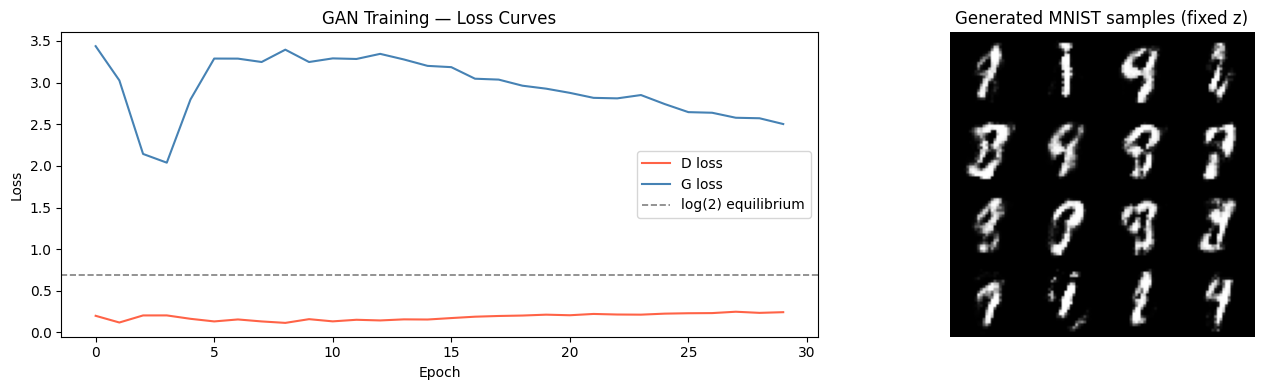


Note: at equilibrium both D and G losses hover near log(2) ≈ 0.693
This means D is at chance (50% accuracy) — exactly what we want!


In [4]:
# ── Visualise training dynamics and generated samples ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Loss curves
axes[0].plot(d_losses, label='D loss', color='tomato')
axes[0].plot(g_losses, label='G loss', color='steelblue')
axes[0].axhline(np.log(2), color='gray', ls='--', lw=1.2, label='log(2) equilibrium')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('GAN Training — Loss Curves')
axes[0].legend()

# Generated samples from fixed_z
G.eval()
with torch.no_grad():
    samples = G(fixed_z).cpu().numpy().reshape(-1, 28, 28)
G.train()

axes[1].axis('off')
axes[1].set_title('Generated MNIST samples (fixed z)')

# 4×4 grid of samples
grid = np.zeros((4*28, 4*28))
for i in range(4):
    for j in range(4):
        grid[i*28:(i+1)*28, j*28:(j+1)*28] = samples[i*4+j]
axes[1].imshow(grid, cmap='gray', vmin=0, vmax=1)

plt.tight_layout()
plt.show()

print('\nNote: at equilibrium both D and G losses hover near log(2) ≈ 0.693')
print('This means D is at chance (50% accuracy) — exactly what we want!')

---
### Comparing GAN vs. VAE samples

Run the cell below to place GAN samples alongside VAE samples from Lec5 side by side.

| | VAE | GAN |
|--|-----|-----|
| Samples | Often blurry | Sharper, more realistic |
| Latent space | Smooth, structured (KL regularised) | Unstructured noise |
| Training | Stable (one ELBO objective) | Can be unstable |
| Density | Explicit lower bound | Implicit only |
| Disentanglement | Easier via β-VAE | Harder |

**Why is GAN sharper?**  
The discriminator has "seen" real MNIST images and provides a **perceptual** signal: it penalises anything that looks statistically unlike real data — including blurriness.  
MSE reconstruction loss doesn't know what "sharp" means.

---
## Part 3 — Conditional GAN (cGAN)

---
### Motivation: the vanilla GAN has no control knob

With a vanilla GAN, $G(z)$ generates a random digit — we can't ask for a specific class.  
**Conditional GAN** (Mirza & Osindero, 2014) fixes this by conditioning both networks on a label $y$:

$$\min_G \max_D \; V(D,G) = \mathbb{E}_{x,y}[\log D(x \mid y)] + \mathbb{E}_{z,y}[\log(1 - D(G(z \mid y) \mid y))]$$

Both $G$ and $D$ receive the class label as an additional input.  
At test time, we can choose any label $y$ to get a digit of that class.

---
### How to inject the label

The standard approach: **embedding + concatenation**

```
Generator:     [z (64-d) | embed(y) (16-d)]  →  784
Discriminator: [x (784)  | embed(y) (16-d)]  →  1
```

The embedding layer $E : \{0,\ldots,9\} \to \mathbb{R}^{16}$ is learned jointly with $G$ and $D$.

In [ ]:
EMBED_DIM = 16
N_CLASSES = 10

class CondGenerator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, embed_dim=EMBED_DIM, n_classes=N_CLASSES):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, embed_dim)
        self.net = nn.Sequential(
            nn.Linear(latent_dim + embed_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 784),
            nn.Sigmoid(),
        )
    def forward(self, z, y):
        emb = self.label_emb(y)          # (B, embed_dim)
        inp = torch.cat([z, emb], dim=1) # (B, latent_dim + embed_dim)
        return self.net(inp)


class CondDiscriminator(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, n_classes=N_CLASSES):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, embed_dim)
        self.net = nn.Sequential(
            nn.Linear(784 + embed_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )
    def forward(self, x, y):
        emb = self.label_emb(y)          # (B, embed_dim)
        inp = torch.cat([x, emb], dim=1) # (B, 784 + embed_dim)
        return self.net(inp)


cG = CondGenerator().to(device)
cD = CondDiscriminator().to(device)

print('Cond-Generator params:    ', sum(p.numel() for p in cG.parameters()))
print('Cond-Discriminator params:', sum(p.numel() for p in cD.parameters()))

In [ ]:
# ── cGAN training loop ────────────────────────────────────────────────────────
opt_cG = optim.Adam(cG.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_cD = optim.Adam(cD.parameters(), lr=2e-4, betas=(0.5, 0.999))

cd_losses, cg_losses = [], []

# Fixed z + labels 0-9 twice for a 2×10 display grid
fixed_z_cgan  = torch.randn(20, LATENT_DIM, device=device)
fixed_y_cgan  = torch.tensor(list(range(10)) * 2, device=device)

for epoch in range(1, N_EPOCHS + 1):
    epoch_d, epoch_g = 0.0, 0.0
    for real_imgs, labels in train_dl:
        real_imgs = real_imgs.to(device)
        labels    = labels.to(device)
        B = real_imgs.size(0)

        real_labels = torch.ones (B, 1, device=device)
        fake_labels = torch.zeros(B, 1, device=device)

        # ── Train cD ─────────────────────────────────────────────────────
        z         = torch.randn(B, LATENT_DIM, device=device)
        fake_imgs = cG(z, labels).detach()

        loss_D = (criterion(cD(real_imgs, labels), real_labels) +
                  criterion(cD(fake_imgs, labels), fake_labels)) / 2

        opt_cD.zero_grad(); loss_D.backward(); opt_cD.step()

        # ── Train cG ─────────────────────────────────────────────────────
        z         = torch.randn(B, LATENT_DIM, device=device)
        fake_imgs = cG(z, labels)
        loss_G    = criterion(cD(fake_imgs, labels), real_labels)

        opt_cG.zero_grad(); loss_G.backward(); opt_cG.step()

        epoch_d += loss_D.item()
        epoch_g += loss_G.item()

    cd_losses.append(epoch_d / len(train_dl))
    cg_losses.append(epoch_g / len(train_dl))

    if epoch % 5 == 0:
        print(f'Epoch {epoch:3d}/{N_EPOCHS}  D_loss={cd_losses[-1]:.4f}  G_loss={cg_losses[-1]:.4f}')

print('cGAN training complete.')

In [ ]:
# ── Show class-conditioned generation ─────────────────────────────────────────
cG.eval()
with torch.no_grad():
    cgan_samples = cG(fixed_z_cgan, fixed_y_cgan).cpu().numpy().reshape(-1, 28, 28)
cG.train()

fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for i in range(2):
    for j in range(10):
        axes[i, j].imshow(cgan_samples[i*10+j], cmap='gray', vmin=0, vmax=1)
        axes[i, j].axis('off')
        if i == 0:
            axes[i, j].set_title(str(j), fontsize=10)
fig.suptitle('cGAN: each column is conditioned on digit label 0–9', fontsize=12)
plt.tight_layout()
plt.show()

print('Observation: each column should visually correspond to the labelled digit.')
print('Conditioning gives us a "dial" to control what class is generated.')

---
## Part 4 — Failure Modes: Mode Collapse and Non-Convergence

---
### Why GANs can fail: the game theory perspective

The GAN minimax game is a **two-player zero-sum game**.  
Nash equilibrium ($p_G = p_{\text{data}}$, $D = 0.5$ everywhere) is the desired solution.  
But gradient descent on two losses **does not guarantee convergence to Nash** — the two gradients can orbit each other indefinitely.

Two canonical failure modes:

| Failure | Symptom | Root cause |
|---------|---------|------------|
| **Mode collapse** | G always generates the same (few) images | G exploits D's blind spots; diversity not rewarded |
| **Non-convergence** | Losses oscillate, samples cycle through modes | Simultaneous gradient updates create limit cycles |

---
### Mode Collapse — Theory

Imagine the data has 10 modes (one per digit).  
The generator discovers that mode $k$ fools the discriminator.  
It concentrates all its probability mass on mode $k$ — **one sharp fake beats ten mediocre ones**.  
The discriminator then learns to reject mode $k$.  
The generator switches to mode $k'$. Repeat — the generator **cycles** through modes without covering them all.

Mathematically: JSD is maximised at $\log 2$ even if $p_G$ covers only one mode (as long as that mode has zero overlap with other real modes).  
JSD does not penalise missing modes.

---
### Non-Convergence — Theory

Consider the simplest possible GAN: data is $x \sim \mathcal{N}(\mu^*, 1)$, generator is $G(z) = z + \mu_G$ (shift).

Optimal D given $\mu_G$: $D^*(x) = \sigma(x - (\mu^* + \mu_G)/2)$ (logistic separator).

Gradient of $G$'s loss w.r.t. $\mu_G$: always points **away** from $\mu^*$ if $\mu_G \neq \mu^*$, but the step size can overshoot, causing $\mu_G$ to oscillate around $\mu^*$ indefinitely.

This happens because D and G update **simultaneously** — each gradient is computed assuming the other's parameters are fixed, but they're not.

In [ ]:
# ── Empirical demonstration: inducing mode collapse ───────────────────────────
# We use a small 2D toy dataset: mixture of 8 Gaussians arranged in a circle.
# A GAN with a severely imbalanced D/G capacity collapses to 1-2 modes.

def make_ring_data(n=2000, radius=2.0, n_modes=8, sigma=0.05):
    """Mixture of `n_modes` Gaussians arranged on a circle."""
    angles = np.linspace(0, 2*np.pi, n_modes, endpoint=False)
    centers = np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1)
    z = np.random.choice(n_modes, size=n)
    data = centers[z] + sigma * np.random.randn(n, 2)
    return data.astype(np.float32), centers

ring_data, ring_centers = make_ring_data()

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(ring_data[:, 0], ring_data[:, 1], s=5, alpha=0.4, c='steelblue')
ax.scatter(ring_centers[:, 0], ring_centers[:, 1], s=80, c='red', zorder=5, label='Mode centers')
ax.set_aspect('equal'); ax.set_title('Ring dataset — 8 modes'); ax.legend()
plt.tight_layout(); plt.show()

In [ ]:
# ── 2D GAN: two versions — balanced vs. overpowered D ─────────────────────────

def make_2d_G(latent_dim=2, width=64):
    return nn.Sequential(
        nn.Linear(latent_dim, width), nn.Tanh(),
        nn.Linear(width, width),      nn.Tanh(),
        nn.Linear(width, 2),
    )

def make_2d_D(width=64):
    return nn.Sequential(
        nn.Linear(2, width),  nn.LeakyReLU(0.2),
        nn.Linear(width, width), nn.LeakyReLU(0.2),
        nn.Linear(width, 1),  nn.Sigmoid(),
    )

def train_2d_gan(real_data, n_epochs=500, lr_G=1e-3, lr_D=1e-3,
                 d_steps=1, latent_dim=2, seed=0):
    """
    d_steps: how many D updates per G update.
    Setting d_steps >> 1 overpowers D and induces mode collapse.
    """
    torch.manual_seed(seed)
    G2 = make_2d_G(latent_dim).to(device)
    D2 = make_2d_D().to(device)
    opt_G2 = optim.Adam(G2.parameters(), lr=lr_G, betas=(0.5, 0.999))
    opt_D2 = optim.Adam(D2.parameters(), lr=lr_D, betas=(0.5, 0.999))
    crit   = nn.BCELoss()

    data_t  = torch.tensor(real_data, device=device)
    B       = 256

    for epoch in range(n_epochs):
        idx2    = torch.randperm(len(data_t))[:B]
        real_b  = data_t[idx2]
        ones    = torch.ones (B, 1, device=device)
        zeros   = torch.zeros(B, 1, device=device)

        for _ in range(d_steps):
            z2    = torch.randn(B, latent_dim, device=device)
            fakes = G2(z2).detach()
            l_D   = (crit(D2(real_b), ones) + crit(D2(fakes), zeros)) / 2
            opt_D2.zero_grad(); l_D.backward(); opt_D2.step()

        z2    = torch.randn(B, latent_dim, device=device)
        fakes = G2(z2)
        l_G   = crit(D2(fakes), ones)
        opt_G2.zero_grad(); l_G.backward(); opt_G2.step()

    # Sample 2000 points from trained G
    G2.eval()
    with torch.no_grad():
        z_samp  = torch.randn(2000, latent_dim, device=device)
        samples = G2(z_samp).cpu().numpy()
    return samples


print('Training balanced GAN (d_steps=1)...')
samples_balanced = train_2d_gan(ring_data, d_steps=1)

print('Training overpowered-D GAN (d_steps=10) — expect mode collapse...')
samples_collapsed = train_2d_gan(ring_data, d_steps=10)

print('Done.')

In [ ]:
# ── Compare balanced vs. collapsed ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def plot_ring(ax, samples, centers, title, color='tomato'):
    ax.scatter(ring_data[:, 0], ring_data[:, 1], s=5, alpha=0.2, c='steelblue', label='Real')
    ax.scatter(samples[:, 0],   samples[:, 1],   s=5, alpha=0.4, c=color,       label='Generated')
    ax.scatter(centers[:, 0],   centers[:, 1],   s=80, c='black', zorder=5,     label='Mode centers')
    ax.set_aspect('equal'); ax.set_title(title, fontsize=11)
    ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
    ax.legend(fontsize=8, loc='upper right')

plot_ring(axes[0], ring_data[:2000], ring_centers, 'Real data (all 8 modes)', color='steelblue')
plot_ring(axes[1], samples_balanced,  ring_centers, 'Balanced GAN (d_steps=1)\n→ covers most modes')
plot_ring(axes[2], samples_collapsed, ring_centers, 'Overpowered D (d_steps=10)\n→ mode collapse', color='orange')

plt.tight_layout()
plt.show()

# Count how many modes are covered (a sample is "at" a mode if it's within 0.3 of the center)
for label, samples in [('Balanced', samples_balanced), ('Collapsed', samples_collapsed)]:
    covered = sum(
        np.any(np.linalg.norm(samples - c, axis=1) < 0.3)
        for c in ring_centers
    )
    print(f'{label:10s}: {covered}/8 modes covered')

---
### Non-Convergence: Oscillating Losses

Unlike VAE training (single objective → guaranteed decrease), GAN loss curves **do not have to go down**.  
Here's what healthy vs. unhealthy training looks like:

| Loss pattern | Interpretation |
|---|---|
| Both losses ~0.693, small fluctuations | Equilibrium — good |
| D loss → 0, G loss → ∞ | D has crushed G — G gets no gradient |
| G loss → 0, D loss → ∞ | G has found a hole in D — mode collapse |
| Both oscillate wildly | Non-convergence / limit cycle |

The cell below simulates non-convergence using a deliberately high learning rate.

In [ ]:
# ── Non-convergence: high LR → oscillation ────────────────────────────────────

def train_2d_gan_track_loss(real_data, n_epochs=300, lr_G=1e-3, lr_D=1e-3, seed=0):
    torch.manual_seed(seed)
    G2 = make_2d_G(2).to(device)
    D2 = make_2d_D().to(device)
    opt_G2 = optim.Adam(G2.parameters(), lr=lr_G, betas=(0.5, 0.999))
    opt_D2 = optim.Adam(D2.parameters(), lr=lr_D, betas=(0.5, 0.999))
    crit   = nn.BCELoss()
    data_t = torch.tensor(real_data, device=device)
    B      = 256
    d_hist, g_hist = [], []

    for epoch in range(n_epochs):
        idx2   = torch.randperm(len(data_t))[:B]
        real_b = data_t[idx2]
        ones   = torch.ones (B, 1, device=device)
        zeros  = torch.zeros(B, 1, device=device)

        z2    = torch.randn(B, 2, device=device)
        fakes = G2(z2).detach()
        l_D   = (crit(D2(real_b), ones) + crit(D2(fakes), zeros)) / 2
        opt_D2.zero_grad(); l_D.backward(); opt_D2.step()

        z2    = torch.randn(B, 2, device=device)
        fakes = G2(z2)
        l_G   = crit(D2(fakes), ones)
        opt_G2.zero_grad(); l_G.backward(); opt_G2.step()

        d_hist.append(l_D.item())
        g_hist.append(l_G.item())

    return d_hist, g_hist


print('Training with stable LR (2e-4)...')
d_stable, g_stable = train_2d_gan_track_loss(ring_data, lr_G=2e-4, lr_D=2e-4)

print('Training with high LR (5e-2) → expect oscillation...')
d_unstab, g_unstab = train_2d_gan_track_loss(ring_data, lr_G=5e-2, lr_D=5e-2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, dl, gl, title in [
    (axes[0], d_stable, g_stable, 'Stable training (lr=2e-4)'),
    (axes[1], d_unstab, g_unstab, 'Unstable training (lr=5e-2) — oscillation'),
]:
    ax.plot(dl, label='D loss', color='tomato',    alpha=0.8)
    ax.plot(gl, label='G loss', color='steelblue', alpha=0.8)
    ax.axhline(np.log(2), color='gray', ls='--', lw=1.2, label='log(2) equilibrium')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title(title); ax.legend()

plt.tight_layout(); plt.show()

---
### Practical Fixes for GAN Failures

| Problem | Fix | Intuition |
|---------|-----|-----------|
| Mode collapse | **Minibatch discrimination** | D receives statistics across the batch, penalises duplicates |
| Mode collapse | **Unrolled GANs** | G optimises against a few future D steps, not current D |
| Non-convergence | **Wasserstein GAN (WGAN)** | Replace JSD with Wasserstein distance → continuous, well-defined gradients |
| D crushes G | **One-sided label smoothing** | Real labels → 0.9 instead of 1.0; reduces overconfident D |
| Training instability | **Gradient penalty (WGAN-GP)** | Penalises $\|\nabla_x D(x)\|$ deviating from 1 (Lipschitz constraint) |
| Both | **Spectral normalisation** | Normalises each weight matrix so it has unit spectral norm |

The cell below demonstrates **one-sided label smoothing** on MNIST — a simple fix that often stabilises training significantly.

In [ ]:
# ── Comparing training with and without label smoothing ───────────────────────

def train_gan_track(train_dl, device, n_epochs=20, label_smooth=1.0, seed=0):
    """
    label_smooth: real label value (1.0 = no smoothing, 0.9 = one-sided smoothing)
    Returns (d_losses, g_losses)
    """
    torch.manual_seed(seed)
    G_ = Generator().to(device)
    D_ = Discriminator().to(device)
    oG = optim.Adam(G_.parameters(), lr=2e-4, betas=(0.5, 0.999))
    oD = optim.Adam(D_.parameters(), lr=2e-4, betas=(0.5, 0.999))
    crit = nn.BCELoss()
    dl_hist, gl_hist = [], []

    for epoch in range(n_epochs):
        epoch_d, epoch_g = 0.0, 0.0
        for real_imgs, _ in train_dl:
            real_imgs = real_imgs.to(device)
            B = real_imgs.size(0)
            real_lbl = torch.full((B, 1), label_smooth, device=device)  # smoothed or 1.0
            fake_lbl = torch.zeros(B, 1, device=device)

            z = torch.randn(B, LATENT_DIM, device=device)
            l_D = (crit(D_(real_imgs), real_lbl) +
                   crit(D_(G_(z).detach()), fake_lbl)) / 2
            oD.zero_grad(); l_D.backward(); oD.step()

            z = torch.randn(B, LATENT_DIM, device=device)
            l_G = crit(D_(G_(z)), torch.ones(B, 1, device=device))
            oG.zero_grad(); l_G.backward(); oG.step()

            epoch_d += l_D.item(); epoch_g += l_G.item()

        dl_hist.append(epoch_d / len(train_dl))
        gl_hist.append(epoch_g / len(train_dl))

    return dl_hist, gl_hist


print('Training without label smoothing...')
d_hard, g_hard = train_gan_track(train_dl, device, n_epochs=20, label_smooth=1.0)

print('Training with one-sided label smoothing (0.9)...')
d_soft, g_soft = train_gan_track(train_dl, device, n_epochs=20, label_smooth=0.9)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, dl, gl, title in [
    (axes[0], d_hard, g_hard, 'No label smoothing'),
    (axes[1], d_soft, g_soft, 'One-sided label smoothing (0.9)'),
]:
    ax.plot(dl, label='D loss', color='tomato')
    ax.plot(gl, label='G loss', color='steelblue')
    ax.axhline(np.log(2), color='gray', ls='--', lw=1.2, label='equilibrium')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title(title); ax.legend()

plt.tight_layout(); plt.show()
print('\nWith smoothing, D loss tends to stay closer to log(2) — less likely to overpower G.')

---
## Summary

| Concept | Formula / Key Idea |
|---------|-------------------|
| VAE → GAN gap | MSE reconstruction → blurry samples; adversarial loss → perceptually sharp |
| GAN objective | $\min_G \max_D \; \mathbb{E}[\log D(x)] + \mathbb{E}[\log(1 - D(G(z)))]$ |
| Optimal D | $D^*(x) = p_{\text{data}} / (p_{\text{data}} + p_G)$ |
| Nash equilibrium | $p_G = p_{\text{data}}$, $D = 0.5$, $V = -\log 4$ |
| Non-saturating G loss | Maximise $\log D(G(z))$ instead of minimising $\log(1 - D(G(z)))$ |
| cGAN | Concatenate label embedding to both G and D inputs |
| Mode collapse | G concentrates on a subset of modes; JSD does not penalise missing modes |
| Non-convergence | Simultaneous gradient updates can orbit Nash without converging |
| Practical fixes | Label smoothing, WGAN, spectral normalisation, minibatch discrimination |